# Phase 1 optimizer -- scheme comparison (Hermite-Simpson vs trapezoidal)

This is one of 7 notebooks in `notebooks/phase1_optimization/`.
Equation/section citations here follow `docs/tt pacing optimizer.md`, the
project's canonical numbering, written as "(design-doc Eq. N)" /
"(design-doc Section N.M)"; display-unit conventions (km/min/km-h⁻¹) are
implemented in `phase_1_0_common.py`'s `as_km`/`as_min`/`as_kmh` helpers, shared
by all 7 notebooks. This one covers
**whether the Hermite-Simpson vs trapezoidal collocation scheme choice matters**.

It is fully self-contained: every rider/course/baseline it needs is
rebuilt here via `phase_1_0_common.py` (shared by all 7 split notebooks),
so it runs standalone from a fresh kernel without any other notebook
having run first. Courses used: flat, rolling (synthetic) + Giro10, TdF16, TARA (real). Approx. runtime: ~4-6 min.

In [1]:
import sys
sys.path.insert(0, ".")
import phase_1_0_common as pc

pc.print_rider_summary()

reference_rider        mass= 72.0 kg  CP= 280.0 W  W'= 20.0 kJ  CdA=0.25 m^2  P_max=   900 W
evenepoel_like_rider   mass= 63.5 kg  CP= 425.0 W  W'= 20.0 kJ  CdA=0.21 m^2  P_max=  1400 W
ganna_like_rider       mass= 82.0 kg  CP= 480.0 W  W'= 20.0 kJ  CdA=0.19 m^2  P_max=  1600 W


### Real courses used in 1.4-1.6

Loaded once here via `phase_1_0_common.load_real_courses()`, which applies
each course's own `smoothing_length_m` (Giro10: 150 m, TdF16: 400 m,
TARA: 250 m) -- real GPX elevation data is genuinely noisy in a way the
synthetic courses below are not, so this parameter matters here in a way
it never does for them.

In [2]:
courses = pc.load_real_courses()
giro10_course, tdf16_course, tara_course = courses["giro10"], courses["tdf16"], courses["tara"]
pc.print_real_course_summary(courses)

Giro 2026 Stage 10   n_nodes= 800  smoothing_length_m=  150 m  mean|grade|= 1.04%  max|grade|=13.20%
TdF 2026 Stage 16    n_nodes= 800  smoothing_length_m=  400 m  mean|grade|= 5.30%  max|grade|=18.53%
TARA 2026 Stage 3    n_nodes= 800  smoothing_length_m=  250 m  mean|grade|= 3.05%  max|grade|=17.56%


## Basic optimization run (design-doc Section 10.2/10.3)

### 1.1 Physics and the collocation transcription

The rider's speed evolves in the distance domain (not time) according to

$$
\frac{dv}{ds} = f_v(v, P, \theta, v_w) \tag{1}
$$

(design-doc Eq. 9), and W'-balance depletes/recovers according to

$$
\frac{dW'_{bal}}{ds} = f_w(v, P, W'_{bal}) \tag{2}
$$

(design-doc Eq. 11, dispatching on the rider's `w_prime_model`).

- $v$ -- rider speed [m/s]
- $s$ -- distance along the course [m]
- $P$ -- crank power [W]
- $\theta$ -- road slope angle [rad]
- $v_w$ -- head-wind component [m/s]
- $W'_{bal}$ -- instantaneous anaerobic-capacity balance [J]

`CollocationProblem` (Section 10 of the design doc) transcribes this
continuous problem onto a distance grid $s_0, s_1, \dots, s_N$. Its
decision vector packs, at every node,

$$
z = (v_0, \dots, v_N,\; W'_{bal,0}, \dots, W'_{bal,N},\; P_0, \dots, P_N \;[,\, P_{mid,0}, \dots, P_{mid,N-1}]) \tag{3}
$$

(design-doc Eq. 40) -- the bracketed midpoint powers $P_{mid,k}$ are extra
free decision variables that exist only for the Hermite-Simpson scheme.

- $N$ -- number of collocation intervals
- $P_{mid,k}$ -- power at the midpoint of interval $k$ [W] (Hermite-Simpson only)

Bounds on the control and a path constraint keep the problem physical:

$$
0 \le P(s) \le P_{max}, \qquad W'_{bal}(s) \ge 0 \tag{4}
$$

(design-doc Eqs. 31-32).

- $P_{max}$ -- the rider's absolute power ceiling [W] (`rider.p_max_W`)

`CollocationProblem(..., scheme=...)` supports two ways of enforcing the
ODEs between adjacent nodes as equality ("defect") constraints:

- **`"hermite_simpson"`** (default): a quadratic-accurate scheme using the
  interpolated midpoint state and the free midpoint control $P_{mid,k}$,

$$
v_{mid,k} - \tfrac{1}{2}(v_k + v_{k+1}) + \tfrac{1}{8}\Delta s_k\,(f_v^k - f_v^{k+1}) = 0 \tag{5}
$$

  and an analogous equation for $W'_{bal,mid,k}$, plus a Simpson-rule
  defect enforcing consistency between the endpoint and midpoint
  derivatives over the interval (design-doc Eqs. 41-42).

  - $\Delta s_k = s_{k+1} - s_k$ -- interval width [m]
  - $f_v^k, f_v^{k+1}$ -- Eq. (1) evaluated at nodes $k$, $k+1$

- **`"trapezoidal"`** (fallback): a lower-order scheme with no midpoint
  state or control,

$$
v_{k+1} - v_k - \tfrac{1}{2}\Delta s_k\,(f_v^k + f_v^{k+1}) = 0 \tag{6}
$$

  (design-doc Eq. 43), and analogously for $W'_{bal}$.

The objective is total time, by quadrature over the same grid:

$$
T = \int_{s_0}^{s_N} \frac{ds}{v(s)} \tag{7}
$$

(design-doc Eq. 44).

Both schemes are run below, with the SLSQP backend, on **two** synthetic
courses -- a near-flat one and a gently rolling one -- and then, in
1.4-1.6, on the same **three** real GPX courses loaded above, each with
its own rider, so the comparison spans synthetic and real terrain alike
and is not just a single-course coincidence.

### 1.2 Flat course

Synthetic near-flat course matching `tests/conftest.py::flat_course`: 40 km,
constant grade 0.1%.

In [3]:
flat_course = pc.build_flat_course()

res_hs_flat, res_trap_flat = pc.run_scheme_comparison(pc.reference_rider, flat_course, pc.calm_wind, pc.N_INTERVALS_BASIC)
opt_hs_flat = pc.ITTOptimizer(pc.reference_rider, flat_course, pc.calm_wind, scheme="hermite_simpson", solver="slsqp")

rel_diff_scheme_flat = pc.report_scheme_comparison(res_hs_flat, res_trap_flat, "flat")

[flat] Hermite-Simpson: T = 57.118 min (success=False)
[flat] Trapezoidal:     T = 57.080 min (success=False)
[flat] Relative difference: 0.00066  (test_trapezoidal_fallback_converges_near_hs_result gate: < 0.02)


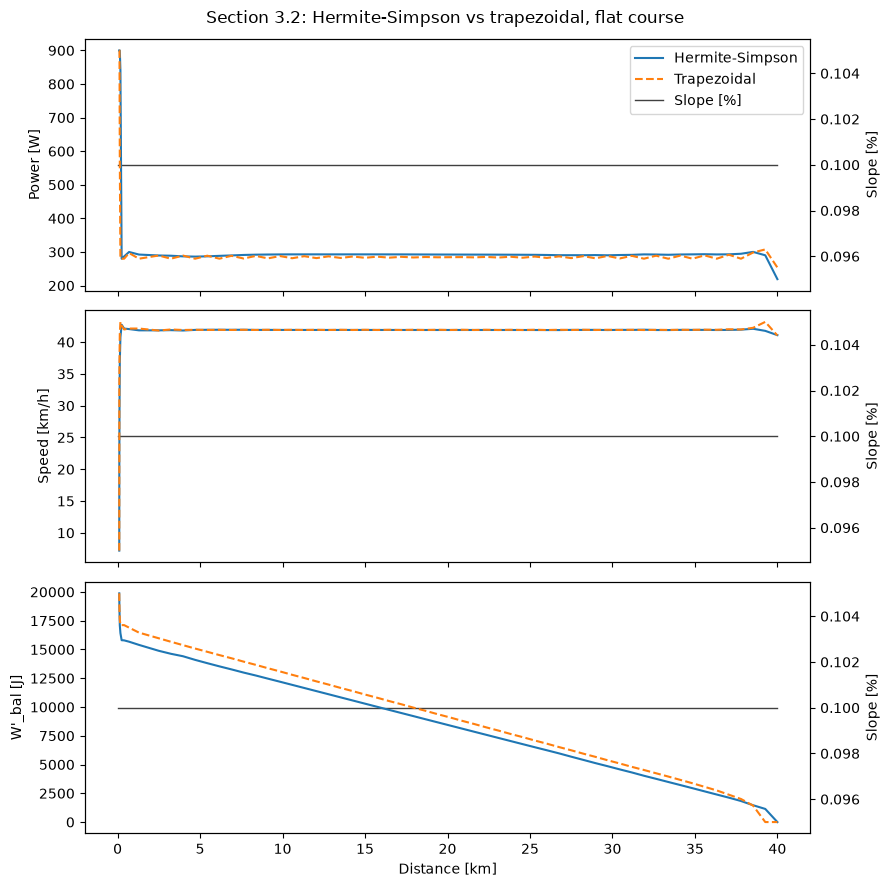

In [4]:
pc.plot_scheme_comparison(res_hs_flat, res_trap_flat, flat_course, "Section 1.2: Hermite-Simpson vs trapezoidal, flat course")

Both schemes agree to well within the test's 2% tolerance -- trapezoidal is
expected to differ somewhat since it is lower-order "by design" (a
deliberate fallback, not a bug). Note `success=False` is possible for
either solve above even though the two schemes agree closely with each
other; the backend-cross-validation notebook addresses why the solver's
own convergence flag is not the notebook's correctness criterion.

### 1.3 Rolling course

A second synthetic course, distinct from the flat one only in terrain: 24 km,
grade oscillating sinusoidally at +-2% amplitude with a 6 km wavelength (4
undulations over the course) -- gentle enough to stay physically ordinary,
but enough to give the optimizer's power trace genuine climb/descend shape
instead of the flat course's near-constant plan. Same rider
(`reference_rider`) and wind (`calm_wind`) as Section 1.2, so terrain is the
only thing that differs.

In [5]:
rolling_course = pc.build_rolling_course()

res_hs_rolling, res_trap_rolling = pc.run_scheme_comparison(pc.reference_rider, rolling_course, pc.calm_wind, pc.N_INTERVALS_BASIC)
opt_hs_rolling = pc.ITTOptimizer(pc.reference_rider, rolling_course, pc.calm_wind, scheme="hermite_simpson", solver="slsqp")

rel_diff_scheme_rolling = pc.report_scheme_comparison(res_hs_rolling, res_trap_rolling, "rolling")
print(f"[rolling] bulk power range: {res_hs_rolling.power_W[9:].min():.0f}-{res_hs_rolling.power_W[9:].max():.0f} W "
      f"(flat course stays near-constant; rolling shows real climb/descend modulation)")

[rolling] Hermite-Simpson: T = 34.056 min (success=False)
[rolling] Trapezoidal:     T = 34.027 min (success=True)
[rolling] Relative difference: 0.00084  (test_trapezoidal_fallback_converges_near_hs_result gate: < 0.02)
[rolling] bulk power range: 184-389 W (flat course stays near-constant; rolling shows real climb/descend modulation)


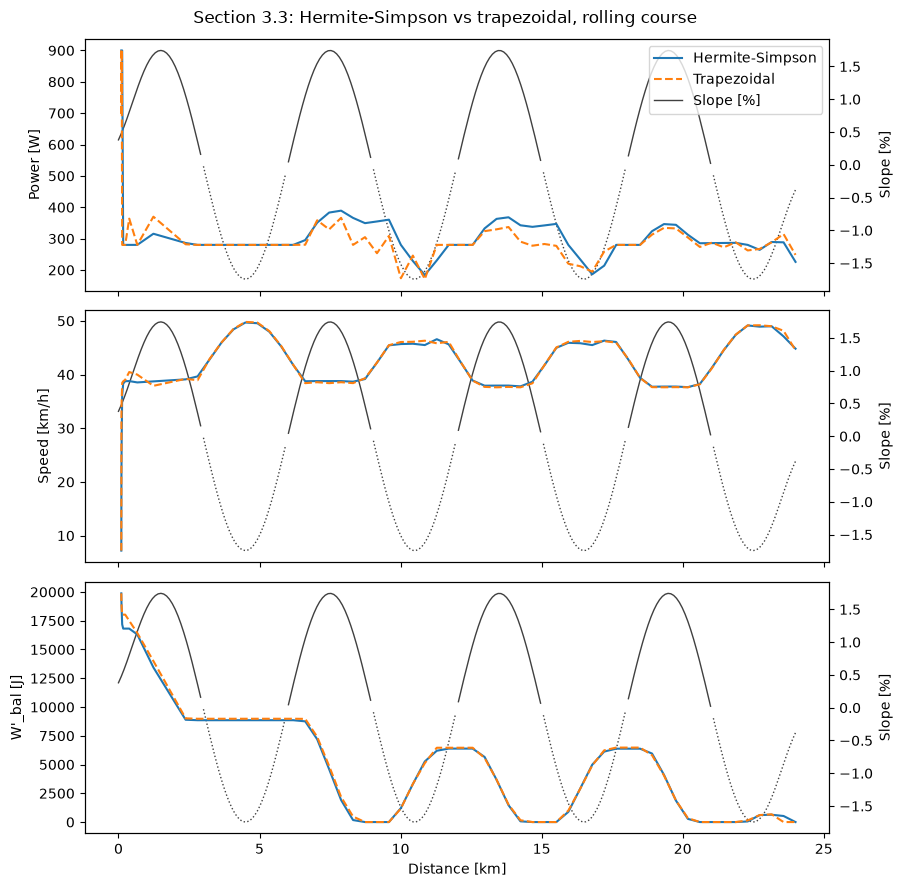

In [6]:
pc.plot_scheme_comparison(res_hs_rolling, res_trap_rolling, rolling_course, "Section 1.3: Hermite-Simpson vs trapezoidal, rolling course")

The rolling course's optimal power trace visibly tracks the grade (higher
on climbs, lower on descents), unlike the flat course's near-constant plan
-- this richer baseline is what makes the constrained/post-hoc smoothing
notebooks' rolling-course demonstration more informative than it would be
on the flat course alone.

### 1.4 Giro 2026 Stage 10 (real, flat)

Same comparison as 1.2/1.3, now on the real `giro10_course` (loaded
above) with `ganna_like_rider` -- Ganna's own rider fixture, since
`reference_rider` never raced this course.

In [7]:
res_hs_giro10, res_trap_giro10 = pc.run_scheme_comparison(
    pc.ganna_like_rider, giro10_course, pc.calm_wind, pc.N_INTERVALS_GIRO10
)
opt_hs_giro10 = pc.ITTOptimizer(
    pc.ganna_like_rider, giro10_course, pc.calm_wind, scheme="hermite_simpson", solver="slsqp"
)

rel_diff_scheme_giro10 = pc.report_scheme_comparison(res_hs_giro10, res_trap_giro10, "giro10")

[giro10] Hermite-Simpson: T = 42.551 min (success=False)
[giro10] Trapezoidal:     T = 42.366 min (success=False)
[giro10] Relative difference: 0.00434  (test_trapezoidal_fallback_converges_near_hs_result gate: < 0.02)


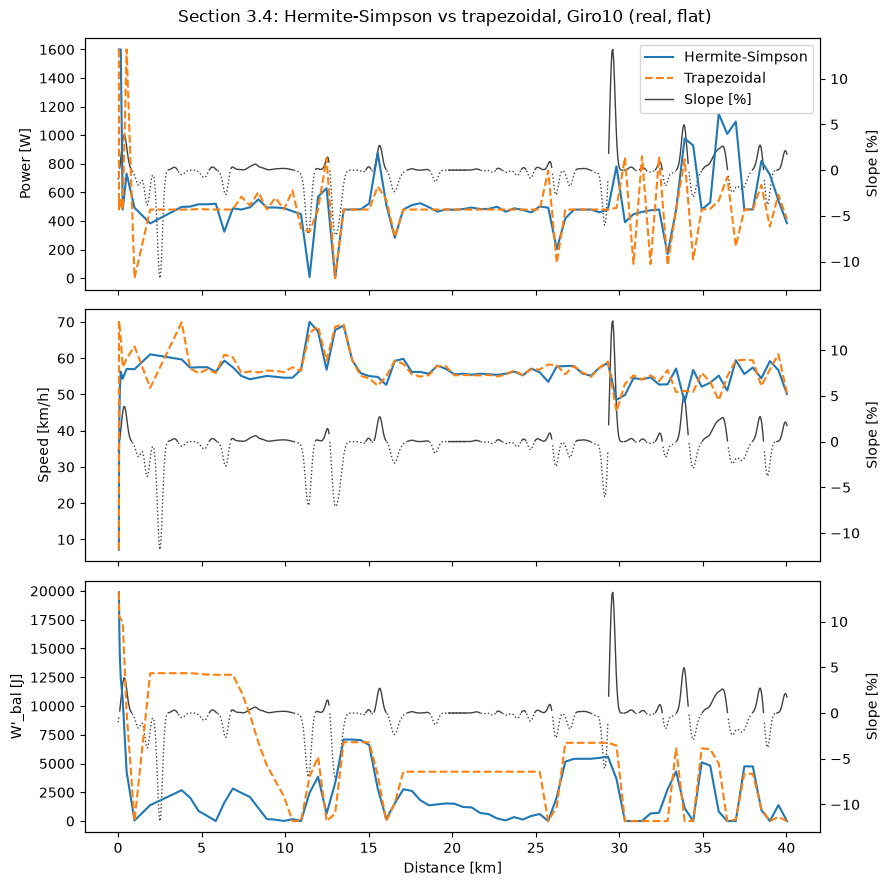

In [8]:
pc.plot_scheme_comparison(res_hs_giro10, res_trap_giro10, giro10_course, "Section 1.4: Hermite-Simpson vs trapezoidal, Giro10 (real, flat)")

Even with real, noisy GPX terrain (light 150 m smoothing), the two
schemes still agree well inside the 2% tolerance (0.43% here, vs.
1.2/1.3's 0.07-0.08%) -- the scheme-choice question 1.1 raises is
independent of whether the course is synthetic or real.

### 1.5 TdF 2026 Stage 16 (real, mountainous)

`evenepoel_like_rider` on `tdf16_course` -- the steepest, most
switchback-heavy terrain in this notebook set, and the first time the
scheme comparison sees sustained double-digit grades.

In [9]:
res_hs_tdf16, res_trap_tdf16 = pc.run_scheme_comparison(
    pc.evenepoel_like_rider, tdf16_course, pc.calm_wind, pc.N_INTERVALS_TDF16
)
opt_hs_tdf16 = pc.ITTOptimizer(
    pc.evenepoel_like_rider, tdf16_course, pc.calm_wind, scheme="hermite_simpson", solver="slsqp"
)

rel_diff_scheme_tdf16 = pc.report_scheme_comparison(res_hs_tdf16, res_trap_tdf16, "tdf16")

[tdf16] Hermite-Simpson: T = 37.192 min (success=False)
[tdf16] Trapezoidal:     T = 37.215 min (success=True)
[tdf16] Relative difference: 0.00063  (test_trapezoidal_fallback_converges_near_hs_result gate: < 0.02)


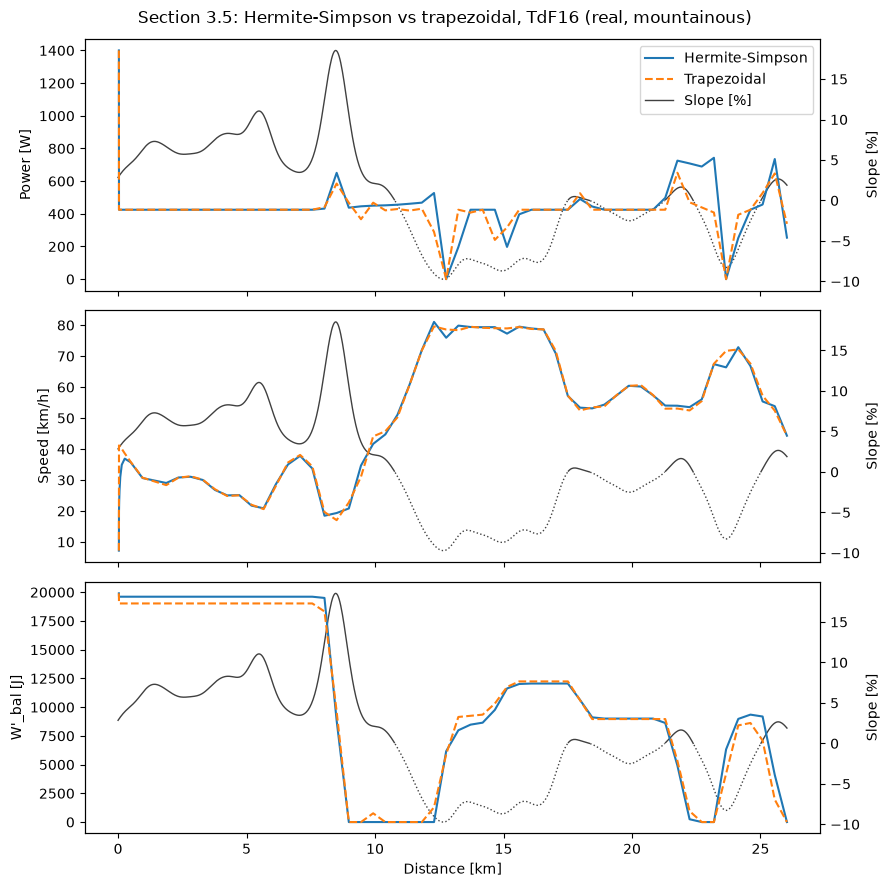

In [10]:
pc.plot_scheme_comparison(res_hs_tdf16, res_trap_tdf16, tdf16_course, "Section 1.5: Hermite-Simpson vs trapezoidal, TdF16 (real, mountainous)")

Unlike the two gentler courses, TdF16's optimal power trace should show
the clearest climb/descend modulation of any course in this notebook set
-- sustained low power on the steepest pitches (bounded by the rider's
own physiology, not the course), recovery on descents.

### 1.6 TARA 2026 Stage 3 (real, rolling/TTT)

`reference_rider` on `tara_course` -- the same rider as the synthetic
courses above, so any difference from 1.2/1.3 here is attributable to
terrain, not physiology.

In [11]:
res_hs_tara, res_trap_tara = pc.run_scheme_comparison(
    pc.reference_rider, tara_course, pc.calm_wind, pc.N_INTERVALS_TARA
)
opt_hs_tara = pc.ITTOptimizer(
    pc.reference_rider, tara_course, pc.calm_wind, scheme="hermite_simpson", solver="slsqp"
)

rel_diff_scheme_tara = pc.report_scheme_comparison(res_hs_tara, res_trap_tara, "tara")

[tara] Hermite-Simpson: T = 45.484 min (success=False)
[tara] Trapezoidal:     T = 45.610 min (success=True)
[tara] Relative difference: 0.00276  (test_trapezoidal_fallback_converges_near_hs_result gate: < 0.02)


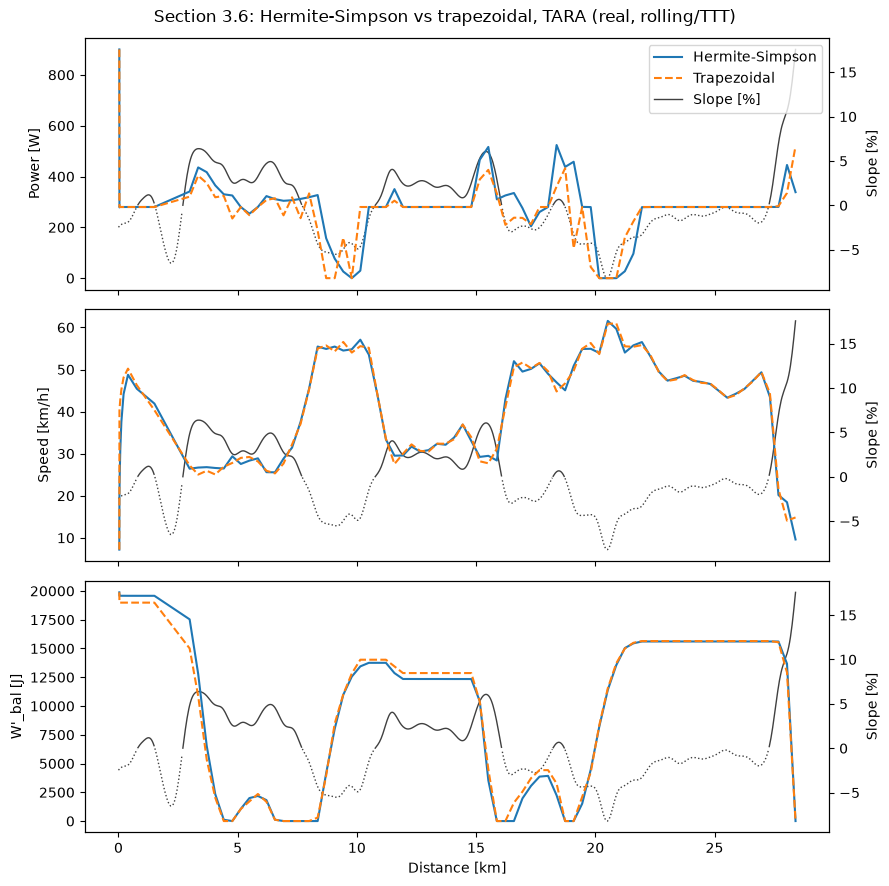

In [12]:
pc.plot_scheme_comparison(res_hs_tara, res_trap_tara, tara_course, "Section 1.6: Hermite-Simpson vs trapezoidal, TARA (real, rolling/TTT)")

TARA's rolling profile sits terrain-wise between Giro10's flat and TdF16's
mountainous extremes, giving a third, intermediate data point for how
strongly the optimal power trace tracks grade.